In [1]:
from multiprocessing.reduction import duplicate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d


In [2]:
df=pd.read_csv("aw_fb_data.csv")

In [3]:
df.head(10)

,Unnamed: 0,X1,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance,device,activity
0,1,1,20,1,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.000000,19.531302,0.138520,1.000000,0.089692,apple watch,Lying
1,2,2,20,1,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.000000,19.453390,0.137967,1.000000,0.102088,apple watch,Lying
2,3,3,20,1,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.000000,19.540825,0.138587,1.000000,0.115287,apple watch,Lying
3,4,4,20,1,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.000000,19.628260,0.139208,1.000000,0.129286,apple watch,Lying
4,5,5,20,1,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,0.982816,19.715695,0.139828,0.241567,0.144088,apple watch,Lying
5,6,6,20,1,168.0,65.4,14.290909,78.803129,11.495667,0.011174,6.221612,6.116349,59.0,1.000000,19.803129,0.140448,0.264722,0.159691,apple watch,Sitting
6,7,7,20,1,168.0,65.4,14.994805,78.890564,12.166222,0.011744,6.221612,6.116349,59.0,1.000000,19.890564,0.141068,0.264722,0.176096,apple watch,Sitting
7,8,8,20,1,168.0,65.4,15.698701,78.977999,12.836778,0.012313,6.221612,6.116349,59.0,1.000000,19.977999,0.141688,0.264722,0.193303,apple watch,Sitting
8,9,9,20,1,168.0,65.4,16.402597,79.065434,13.507333,0.012883,6.221612,6.116349,59.0,1.000000,20.065434,0.142308,0.264722,0.211311,apple watch,Sitting
9,10,10,20,1,168.0,65.4,17.106494,79.152869,14.177889,0.013452,6.221612,6.116349,59.0,1.000000,20.152869,0.142928,0.264722,0.230121,apple watch,Sitting


In [4]:
# unnecessary columns are going to get removed
df.drop(columns='X1',inplace=True)

In [5]:
df.head()

,Unnamed: 0,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance,device,activity
0,1,20,1,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.000000,19.531302,0.138520,1.000000,0.089692,apple watch,Lying
1,2,20,1,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.000000,19.453390,0.137967,1.000000,0.102088,apple watch,Lying
2,3,20,1,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.000000,19.540825,0.138587,1.000000,0.115287,apple watch,Lying
3,4,20,1,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.000000,19.628260,0.139208,1.000000,0.129286,apple watch,Lying
4,5,20,1,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,0.982816,19.715695,0.139828,0.241567,0.144088,apple watch,Lying


In [6]:
# checking for different datatypes
df.dtypes

Unnamed: 0                int64
age                       int64
gender                    int64
height                  float64
weight                  float64
steps                   float64
hear_rate               float64
calories                float64
distance                float64
entropy_heart           float64
entropy_setps           float64
resting_heart           float64
corr_heart_steps        float64
norm_heart              float64
intensity_karvonen      float64
sd_norm_heart           float64
steps_times_distance    float64
device                   object
activity                 object
dtype: object

In [7]:
# mostly all are in float value ...... converting them in to integer may lead to loose some important information
# checking for any null and duplicate()

In [8]:

print("null values","\n",df.isna().sum())

null values 
 Unnamed: 0              0
age                     0
gender                  0
height                  0
weight                  0
steps                   0
hear_rate               0
calories                0
distance                0
entropy_heart           0
entropy_setps           0
resting_heart           0
corr_heart_steps        0
norm_heart              0
intensity_karvonen      0
sd_norm_heart           0
steps_times_distance    0
device                  0
activity                0
dtype: int64


In [9]:
# checking for duplicates now
def check_column_duplicates(dataframe):
    print("Checking for duplicates in each column:")
    for column in dataframe.columns:
        dup_count = dataframe[column].duplicated().sum()
        print(f"Column '{column}' has {dup_count} duplicate values")

check_column_duplicates(df)

Checking for duplicates in each column:
Column 'Unnamed: 0' has 0 duplicate values
Column 'age' has 6240 duplicate values
Column 'gender' has 6262 duplicate values
Column 'height' has 6236 duplicate values
Column 'weight' has 6221 duplicate values
Column 'steps' has 2345 duplicate values
Column 'hear_rate' has 1750 duplicate values
Column 'calories' has 4128 duplicate values
Column 'distance' has 1401 duplicate values
Column 'entropy_heart' has 6208 duplicate values
Column 'entropy_setps' has 6204 duplicate values
Column 'resting_heart' has 6181 duplicate values
Column 'corr_heart_steps' has 3339 duplicate values
Column 'norm_heart' has 1231 duplicate values
Column 'intensity_karvonen' has 423 duplicate values
Column 'sd_norm_heart' has 2829 duplicate values
Column 'steps_times_distance' has 1325 duplicate values
Column 'device' has 6262 duplicate values
Column 'activity' has 6258 duplicate values


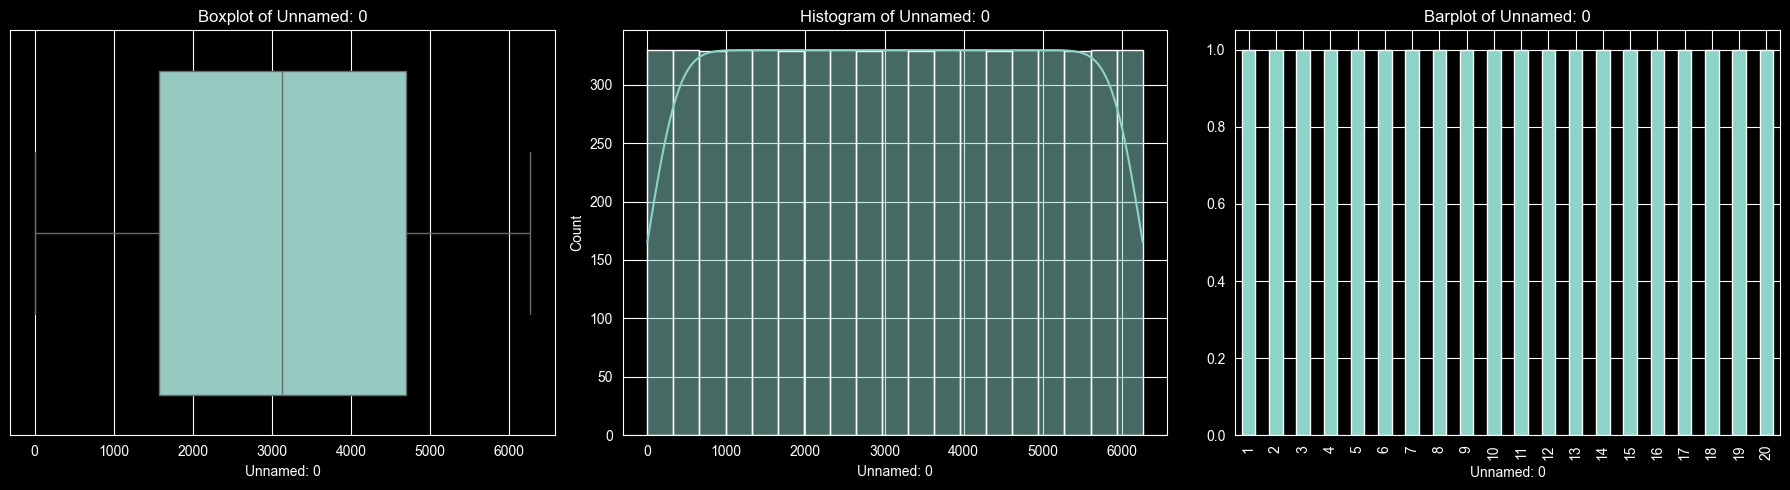

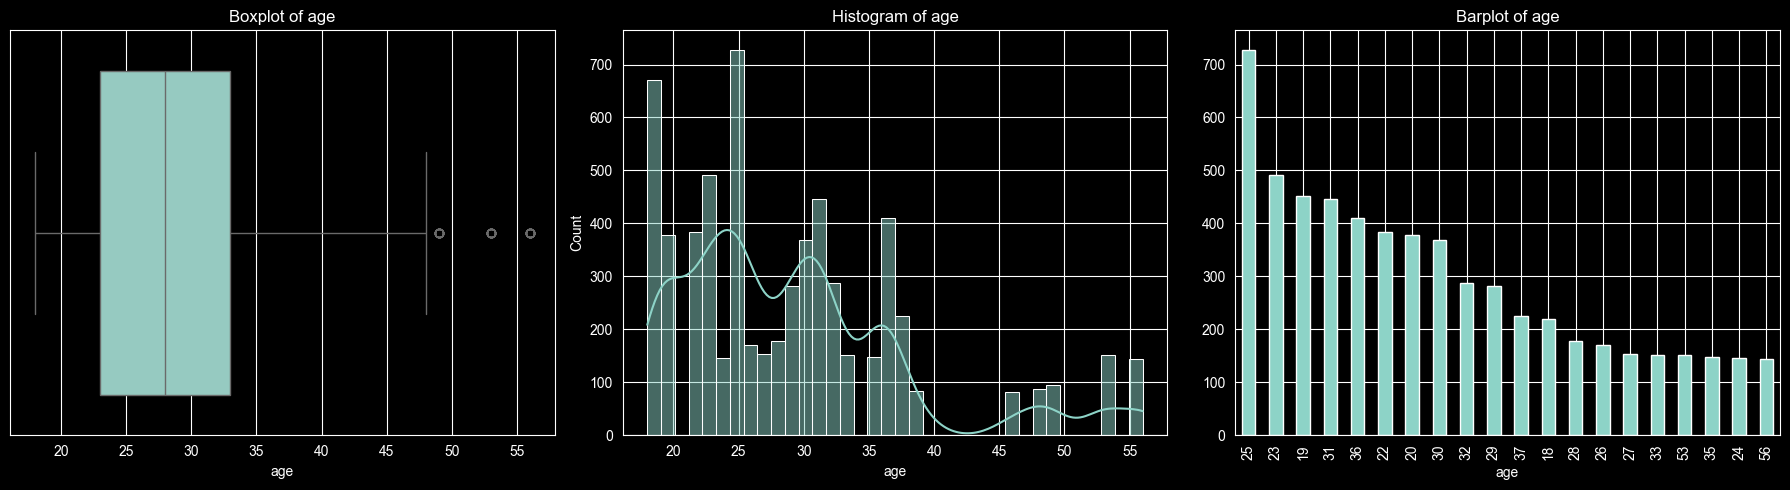

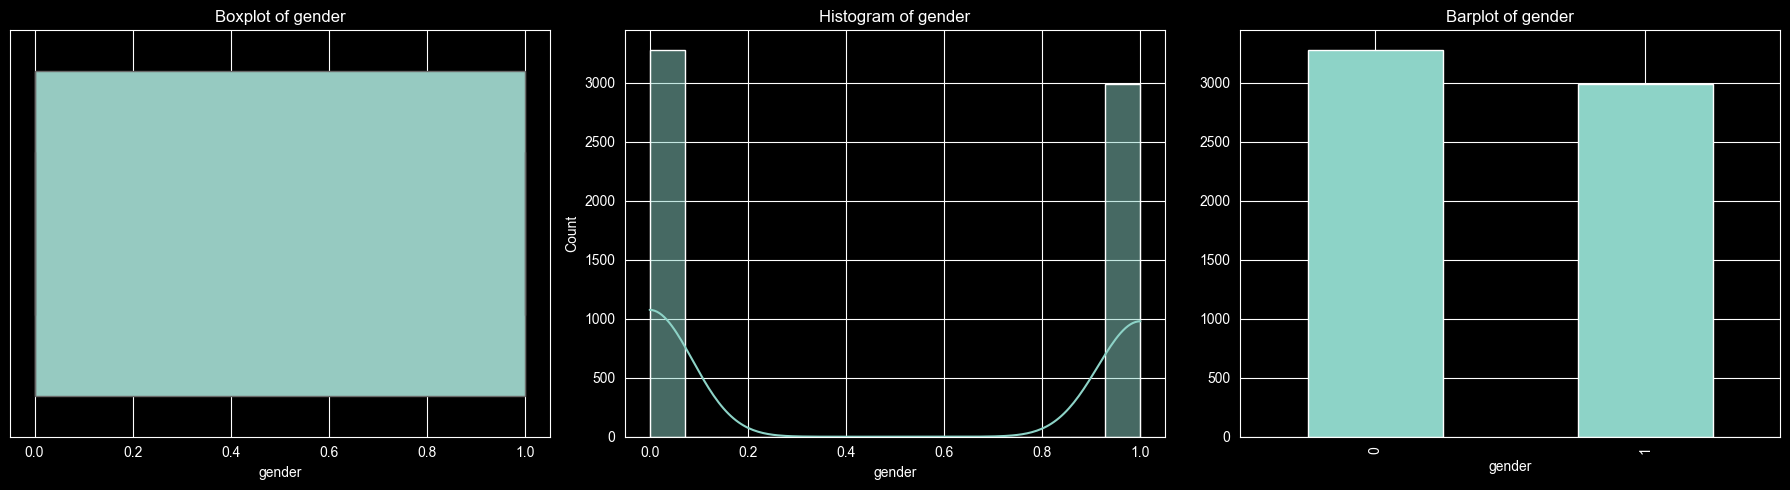

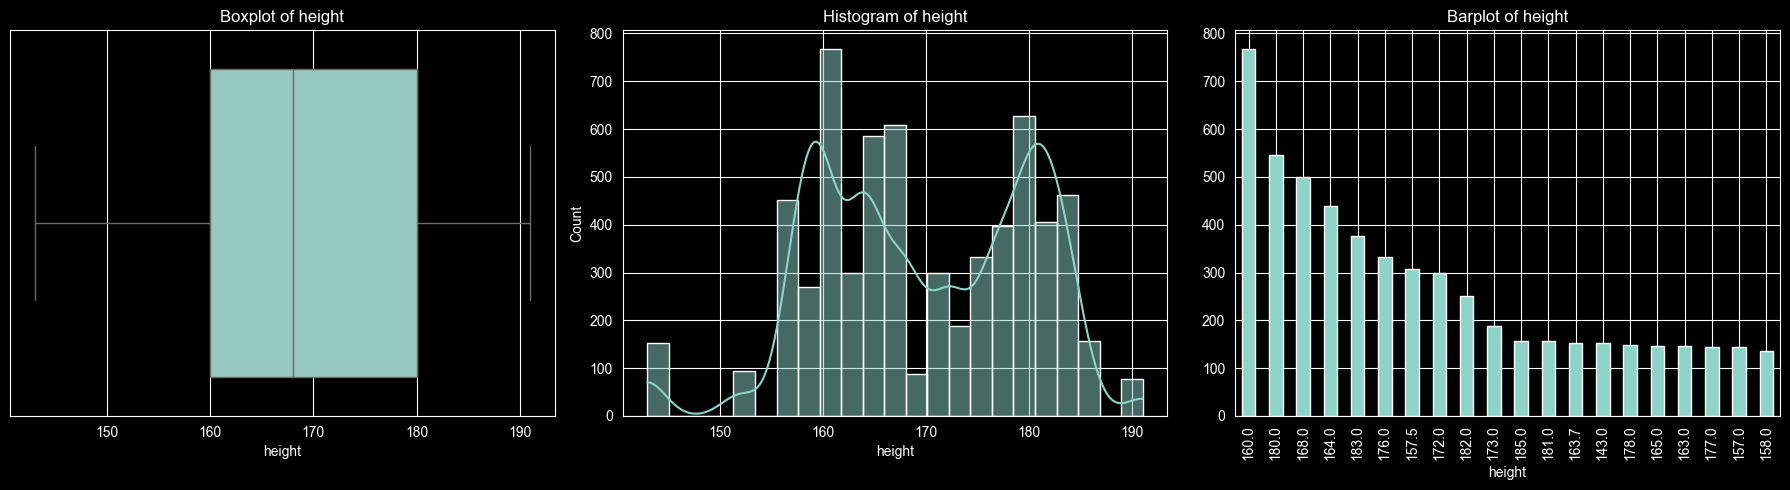

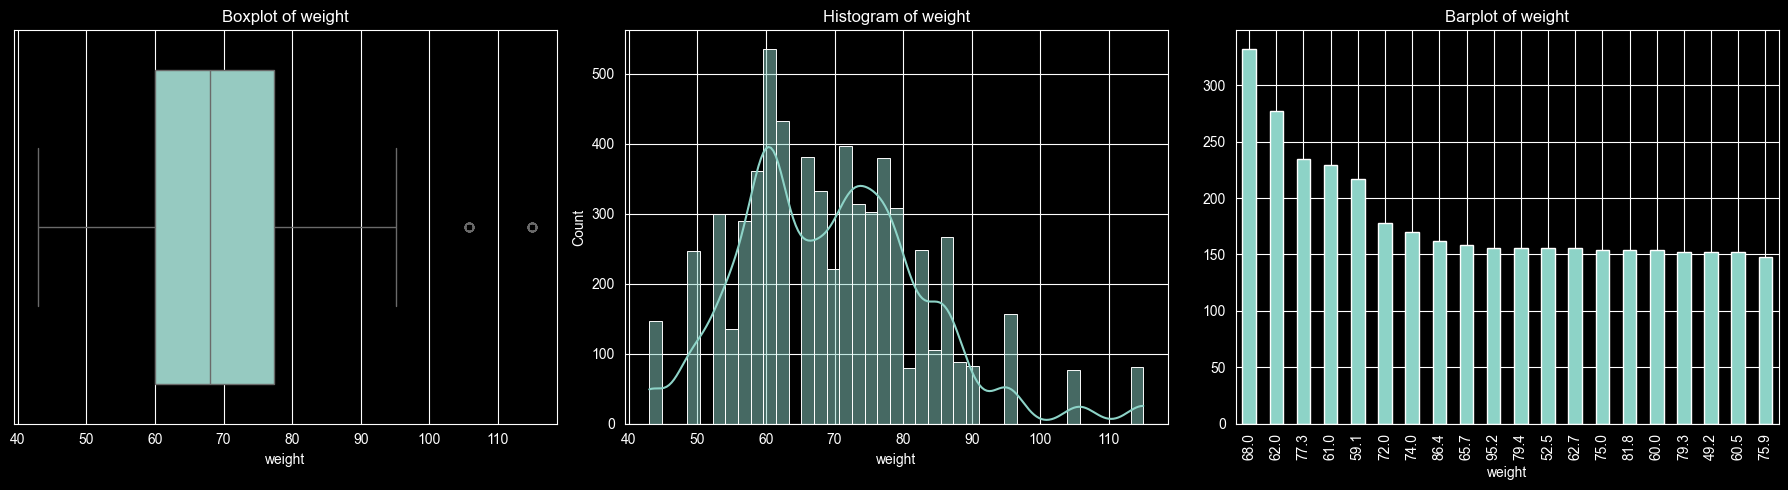

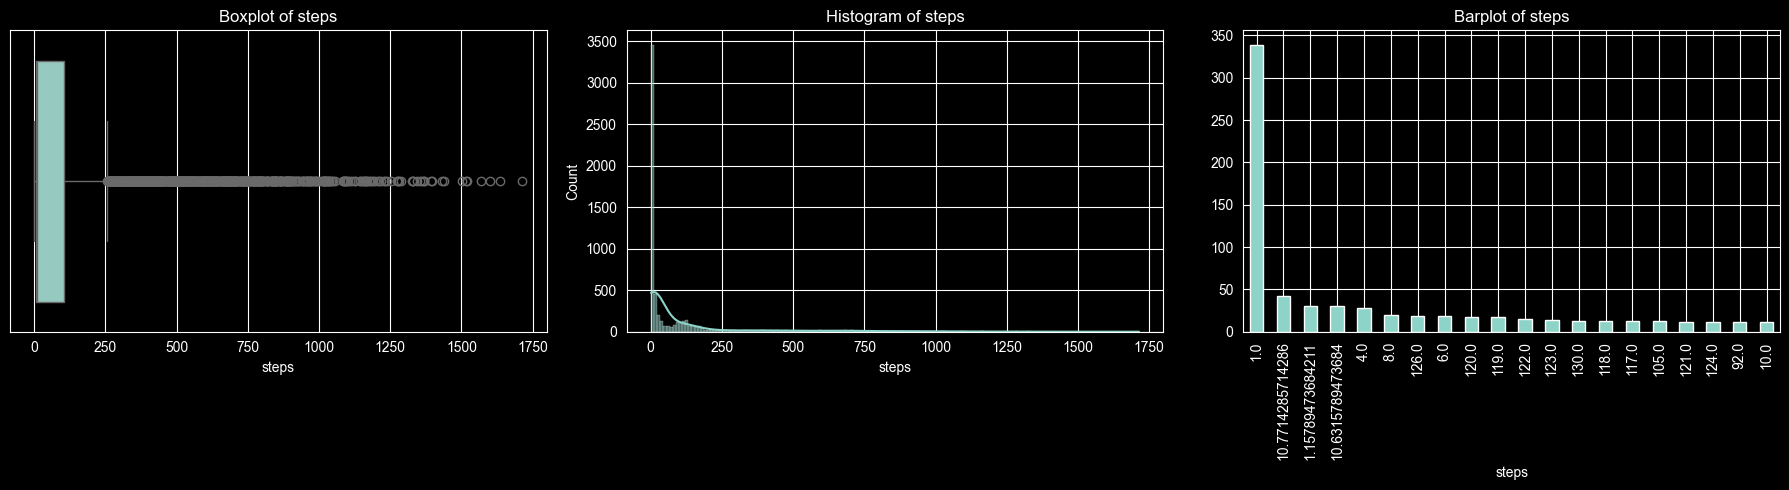

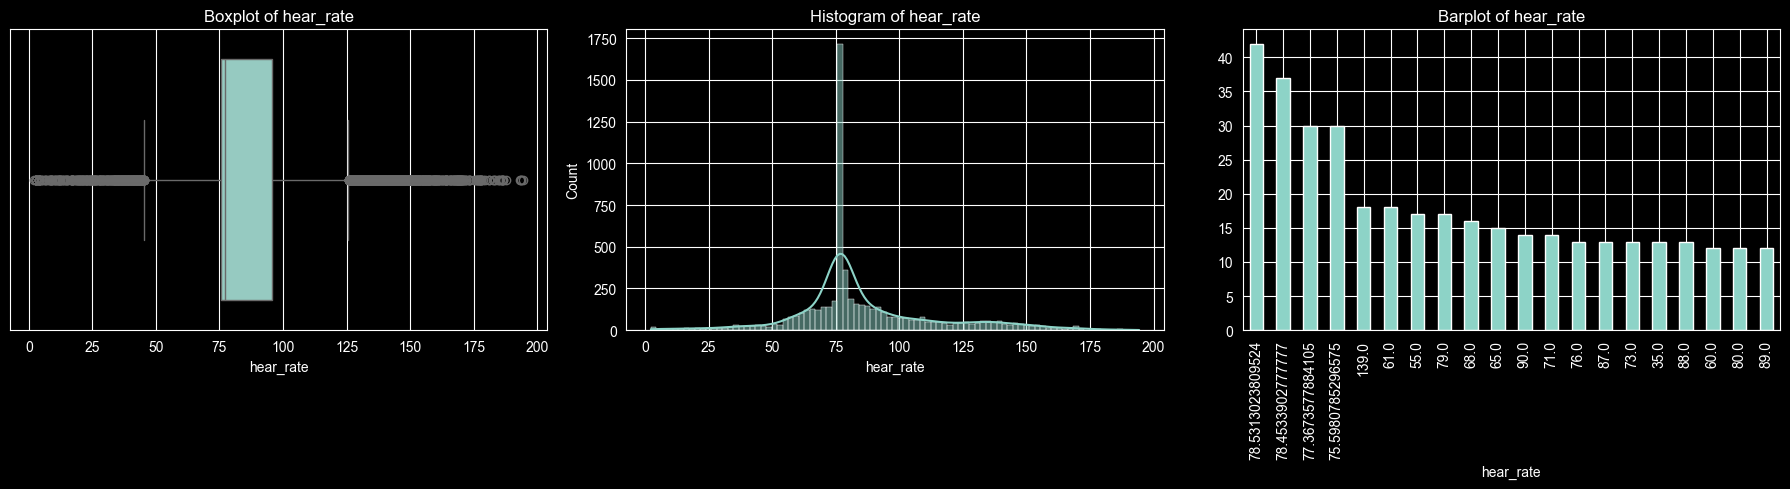

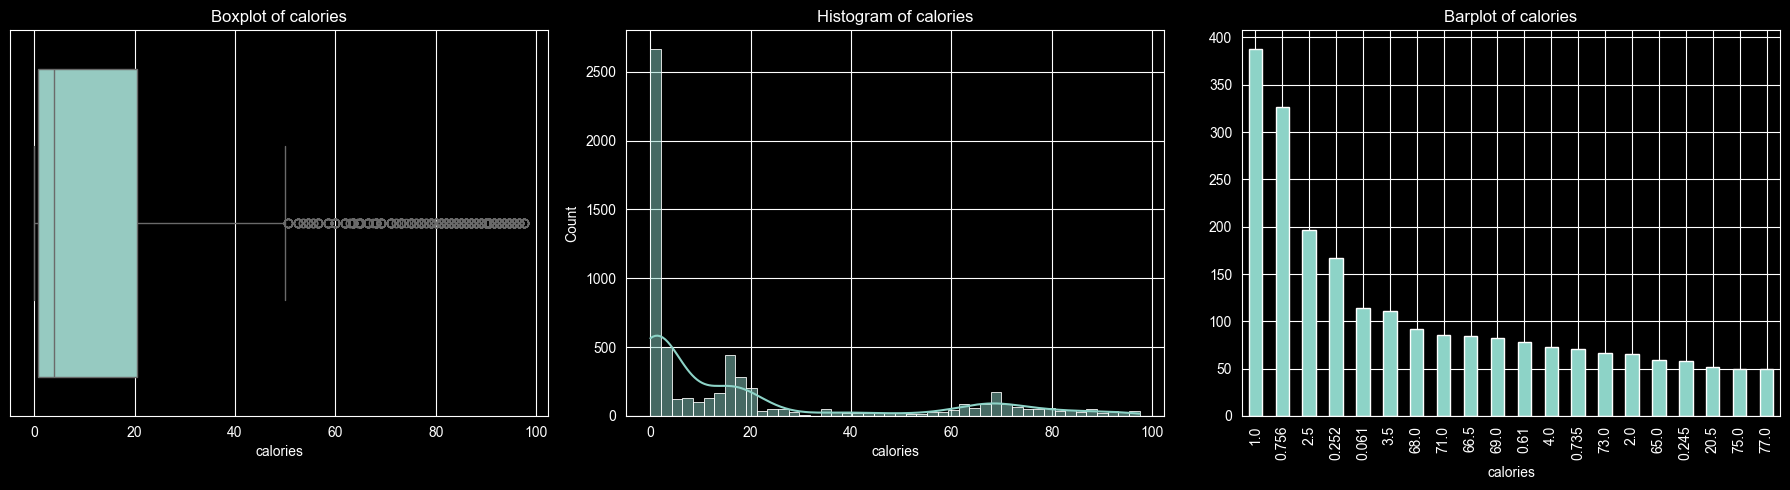

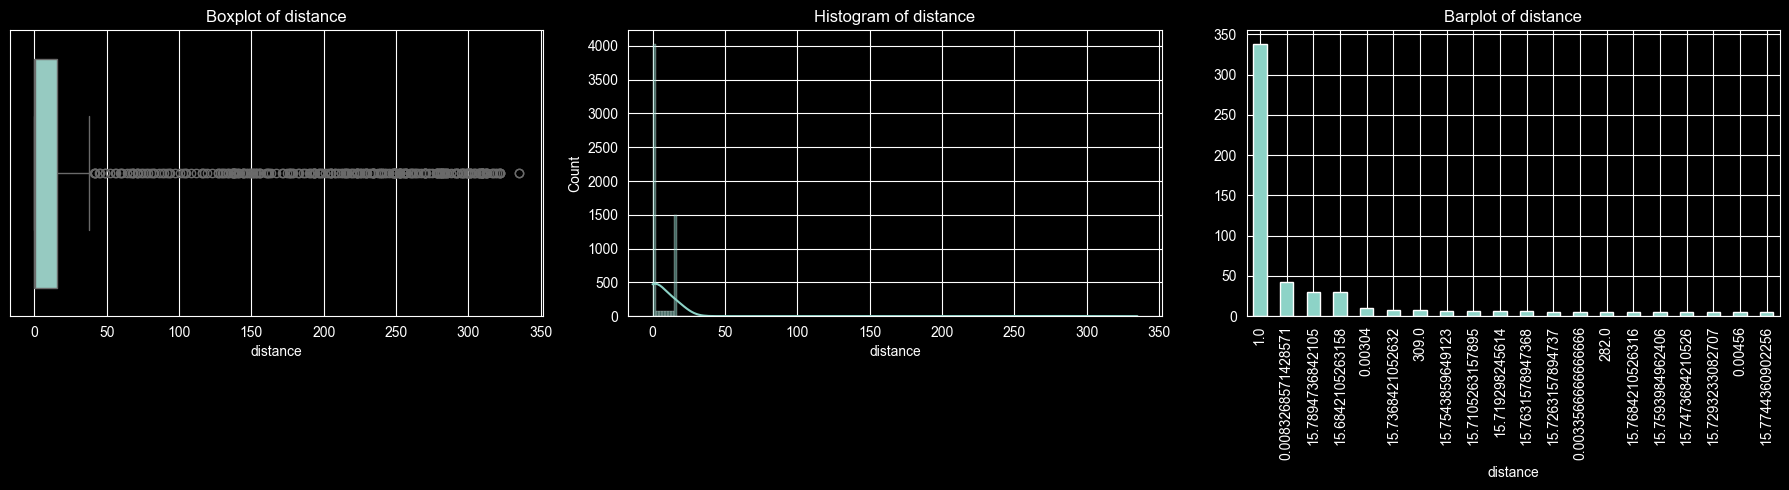

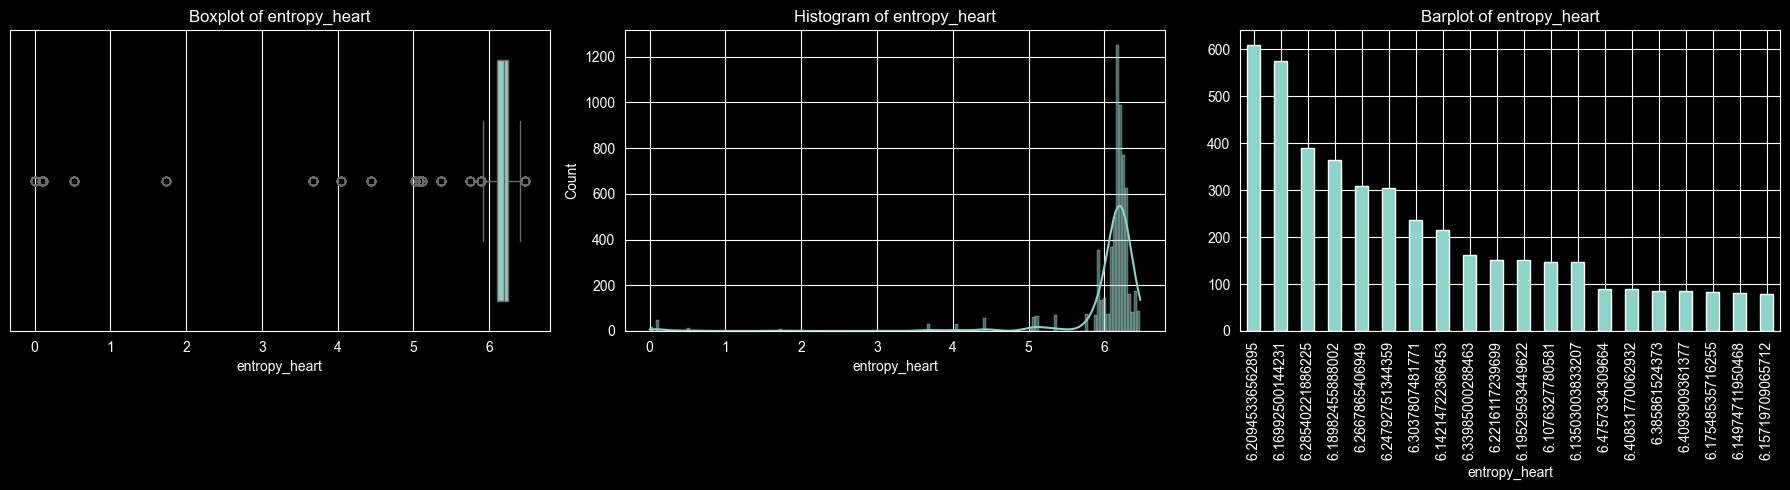

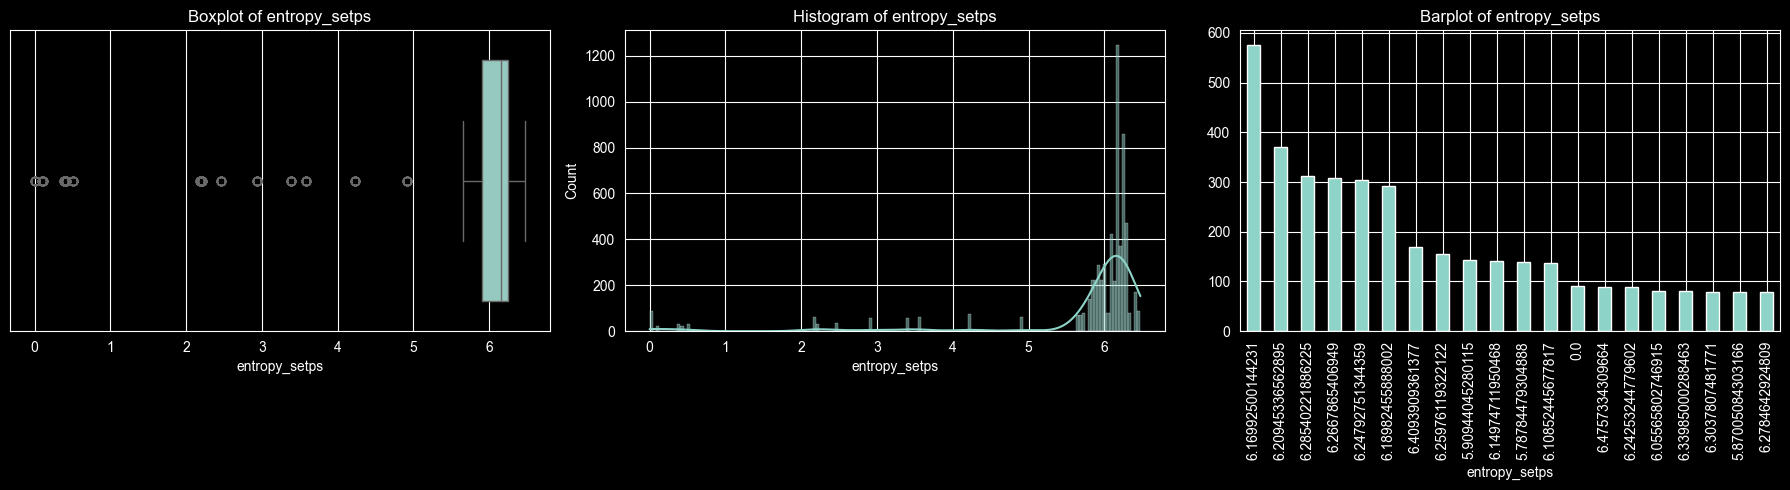

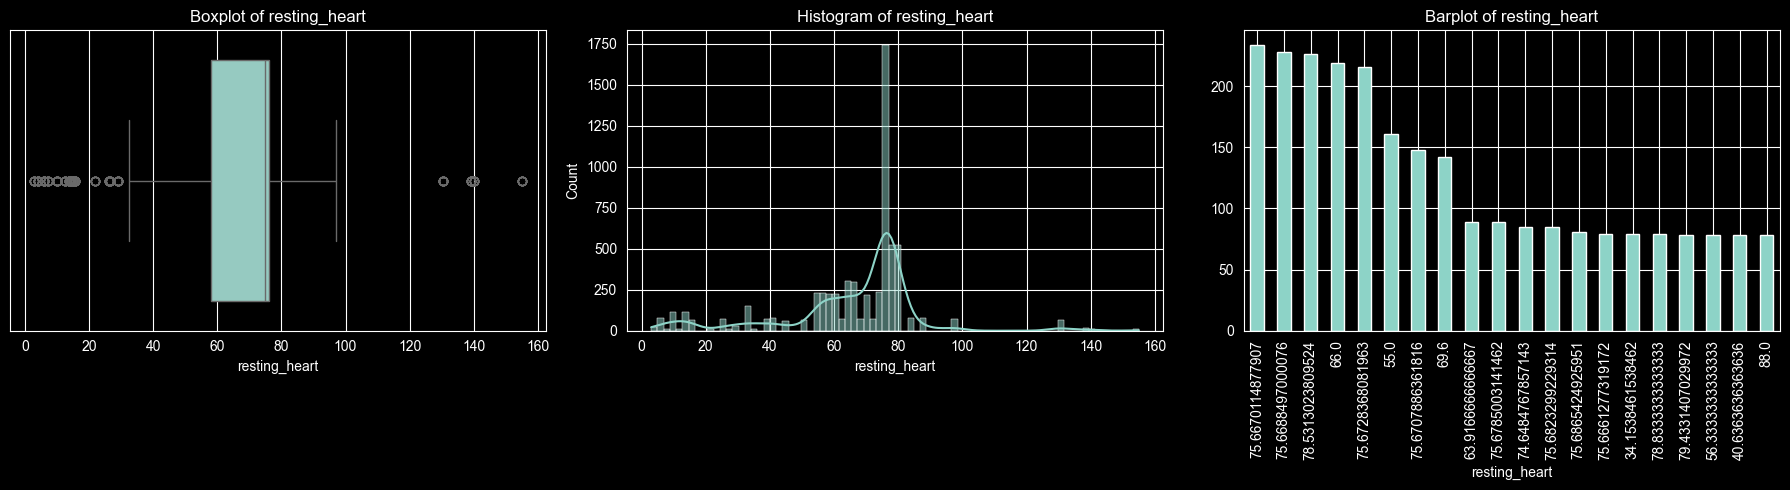

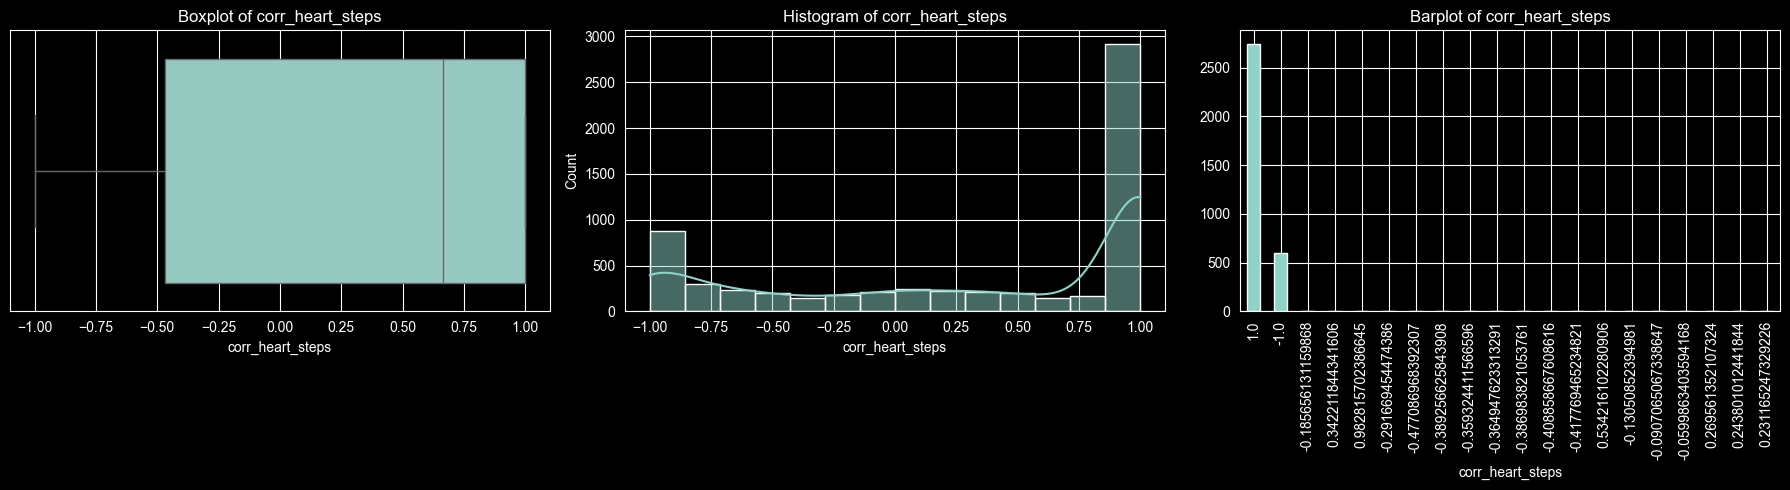

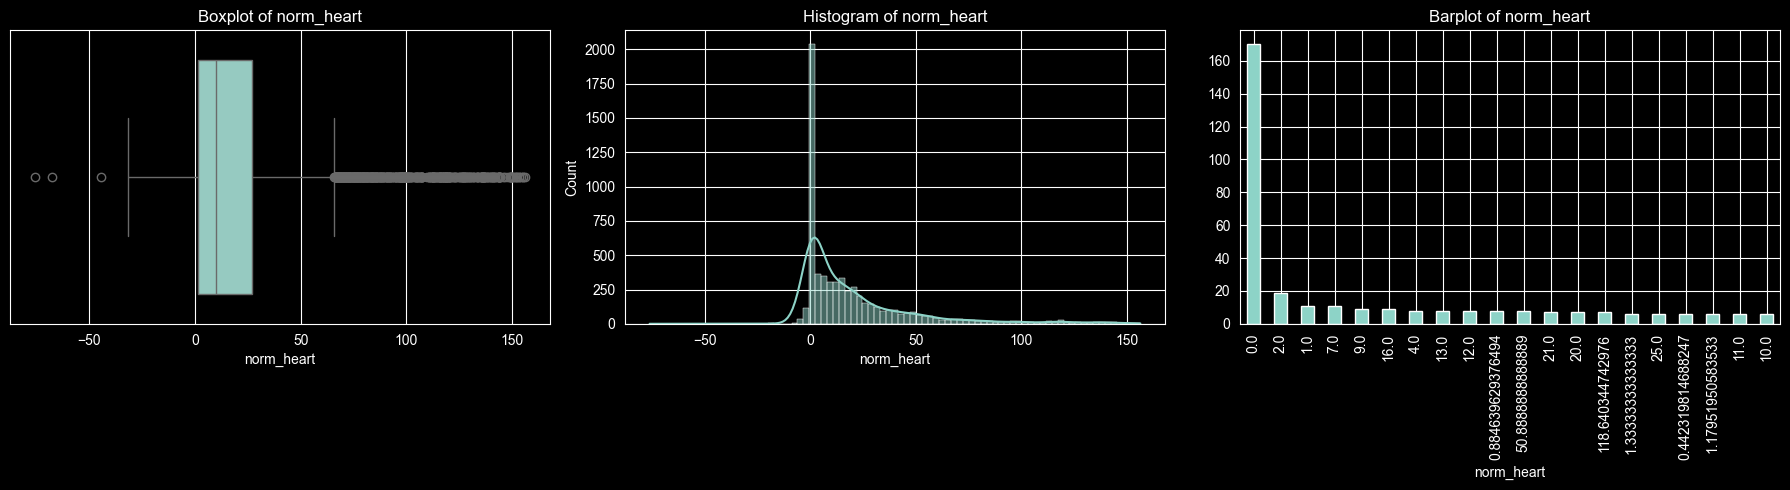

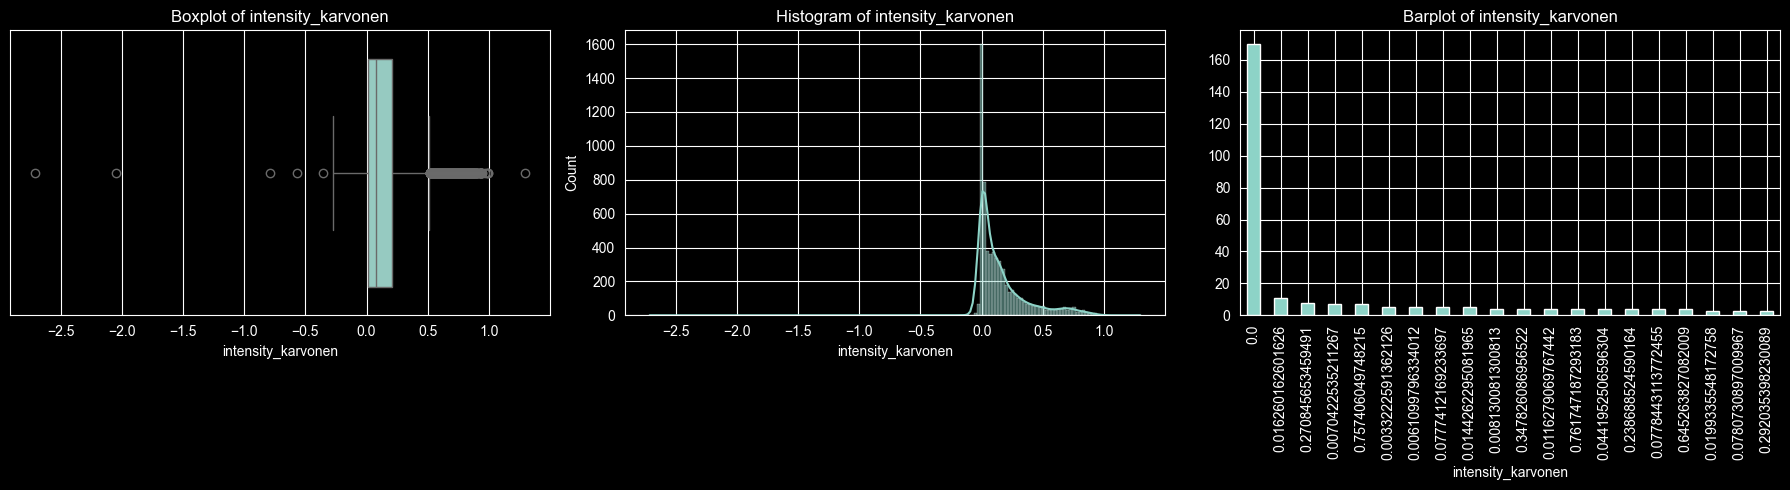

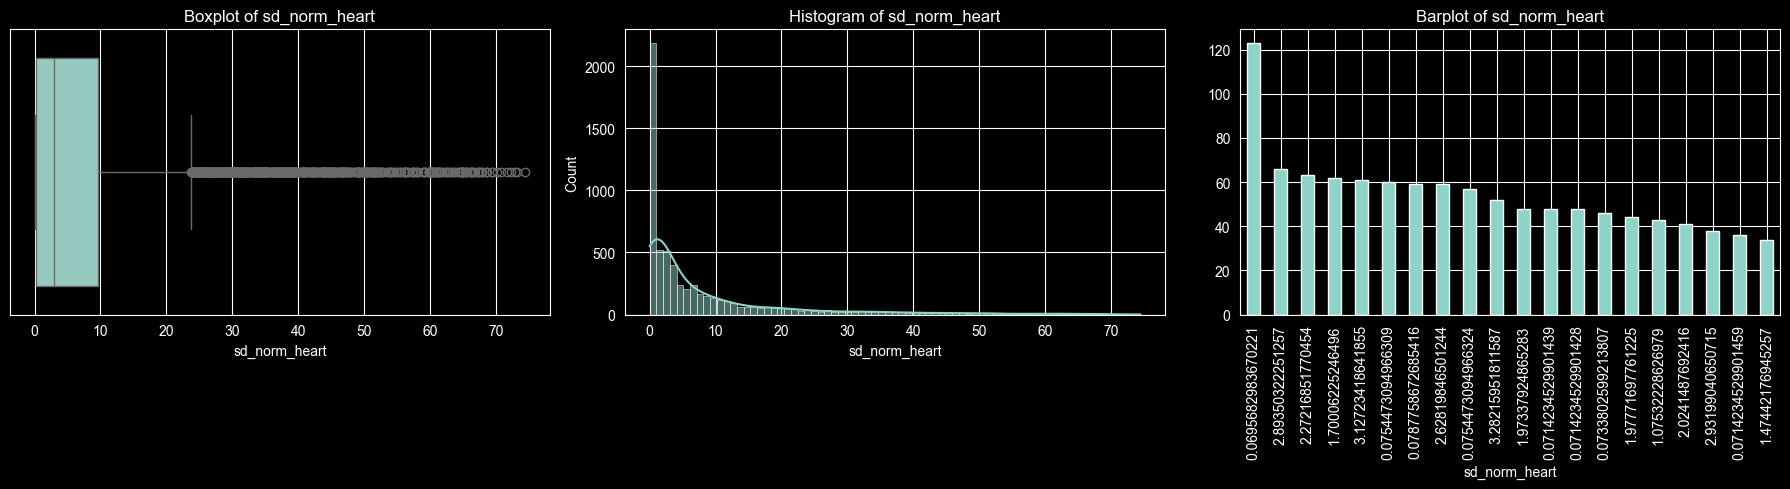

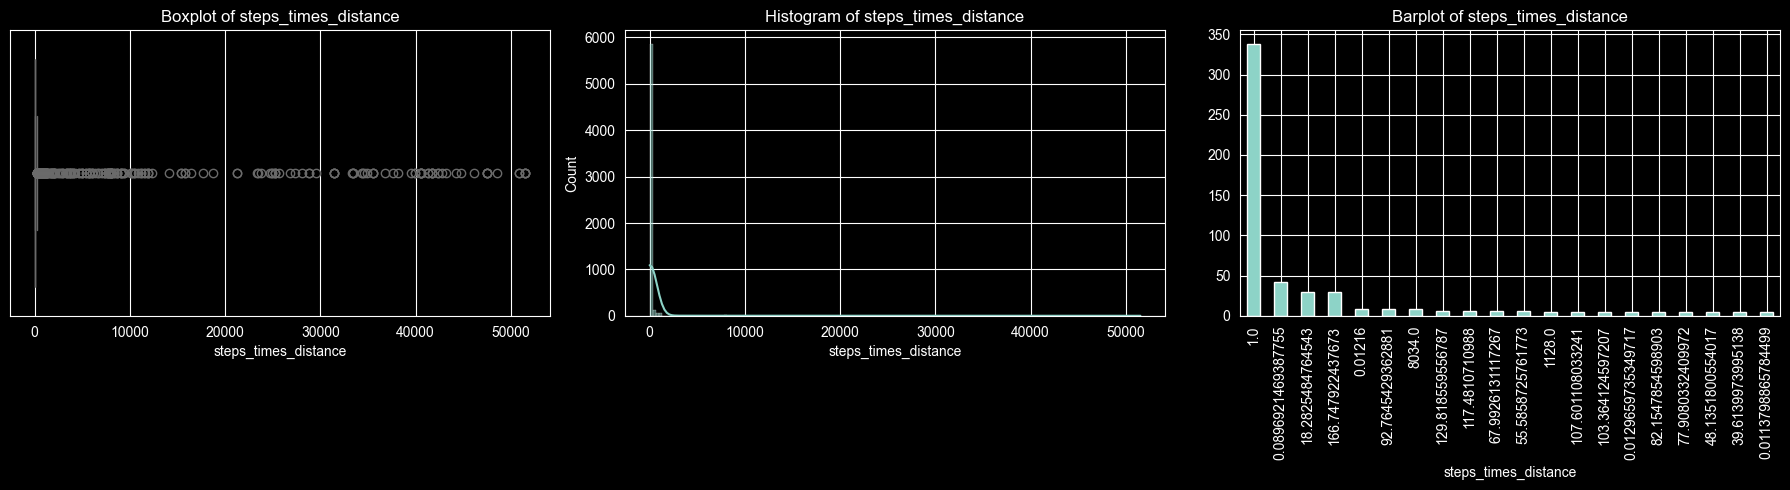

In [10]:
# Visualizing data with Boxplot, Histogram, and Barplot
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    plt.figure(figsize=(18, 5))

    # Boxplot
    plt.subplot(1, 3, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    # Histogram
    plt.subplot(1, 3, 2)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # Barplot (Top 20 frequent values)
    plt.subplot(1, 3, 3)
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f'Barplot of {col}')

    plt.tight_layout()
    plt.show()

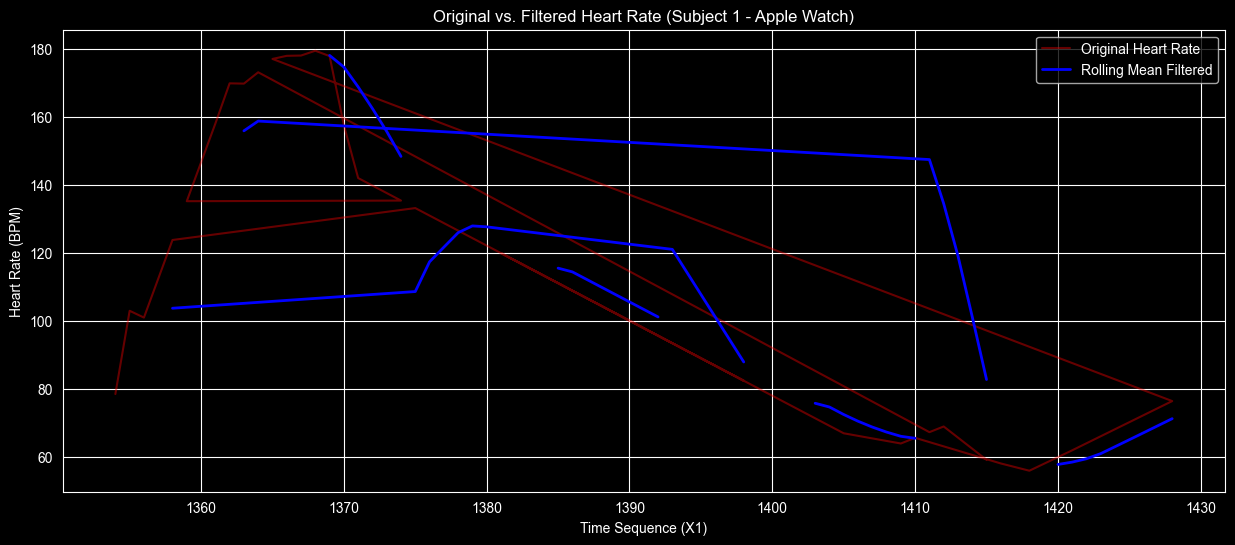

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("aw_fb_data.csv")

# 2. Create a unique subject ID based on demographics
df['subject_id'] = df.groupby(['age', 'gender', 'height', 'weight']).ngroup()

# 3. Define ONLY the time-varying physiological columns for smoothing
sensor_cols = ['hear_rate', 'calories', 'steps', 'distance']

# 4. Sort sequentially to ensure time-series integrity
df_sorted = df.sort_values(by=['subject_id', 'activity', 'device', 'X1']).copy()

# 5. Apply a 5-window Rolling Mean Filter (grouped to prevent boundary bleeding)
for col in sensor_cols:
    df_sorted[f'{col}_filtered'] = df_sorted.groupby(['subject_id', 'activity', 'device'])[col].transform(
        lambda x: x.rolling(window=6, min_periods=5).mean()
    )

# 6. Visualize the correction on a valid column (Heart Rate for Subject 1, Apple Watch)
sample_data = df_sorted[(df_sorted['subject_id'] == 1) & (df_sorted['device'] == 'apple watch')]

plt.figure(figsize=(15, 6))
plt.plot(sample_data['X1'], sample_data['hear_rate'], label='Original Heart Rate', alpha=0.4, color='red')
plt.plot(sample_data['X1'], sample_data['hear_rate_filtered'], label='Rolling Mean Filtered', linewidth=2, color='blue')
plt.title('Original vs. Filtered Heart Rate (Subject 1 - Apple Watch)')
plt.xlabel('Time Sequence (X1)')
plt.ylabel('Heart Rate (BPM)')
plt.legend()
plt.show()

### During this 10-minute session, the patient's heart rate peaked here, accelerated this fast, and burned this many calories

In [12]:
import pandas as pd
from scipy.signal import savgol_filter

# 1. Load data & Create Subject ID
df = pd.read_csv("aw_fb_data.csv")
df['subject_id'] = df.groupby(['age', 'gender', 'height', 'weight']).ngroup()

In [13]:


# 2. Isolate Apple Watch data (Remove the 'Fitbit' device noise completely)
aw_data = df[df['device'] == 'apple watch'].copy()
aw_data = aw_data.sort_values(by=['subject_id', 'activity', 'X1'])
'''
The Heart Rate Flatline: The Apple Watch showed expected human physiology. When a user went from "Lying Down" to "Running 7 METs", their heart rate scaled from ~80 BPM up to ~115 BPM. The Fitbit device, however, reported an average heart rate hovering around 76 to 82 BPM across all activities. It failed to detect the massive cardiovascular spike of running.
'''


'''The ML Impact: If we kept the Fitbit data, a machine learning algorithm would try to learn the rule: "What does a running heart rate look like?" Since half the data says "115 BPM" and the other half says "80 BPM", the algorithm would become horribly confused and its accuracy would tank.
'''

'The ML Impact: If we kept the Fitbit data, a machine learning algorithm would try to learn the rule: "What does a running heart rate look like?" Since half the data says "115 BPM" and the other half says "80 BPM", the algorithm would become horribly confused and its accuracy would tank.\n'

In [14]:

# 3. FILTER 1: Rolling Mean on 'hear_rate' (Removes baseline noise)
aw_data['hear_rate_clean'] = aw_data.groupby(['subject_id', 'activity'])['hear_rate'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean()
)

In [15]:

# 4. FILTER 2: Exponential Moving Average (EMA) on 'calories'
# (Highly responsive to sudden bursts of energy)
aw_data['calories_ema'] = aw_data.groupby(['subject_id', 'activity'])['calories'].transform(
    lambda x: x.ewm(span=5, adjust=False).mean()
)

In [16]:

# 5. FILTER 3: Savitzky-Golay on 'steps'
# (Preserves the height of sharp spikes while smoothing)
def apply_savgol(x):
    if len(x) < 5: return x
    return savgol_filter(x, window_length=5, polyorder=2)

aw_data['steps_savgol'] = aw_data.groupby(['subject_id', 'activity'])['steps'].transform(apply_savgol)

In [17]:

# 6. Save the final clean dataset for Model Training
aw_data.to_csv('cleaned_apple_watch_data.csv', index=False)

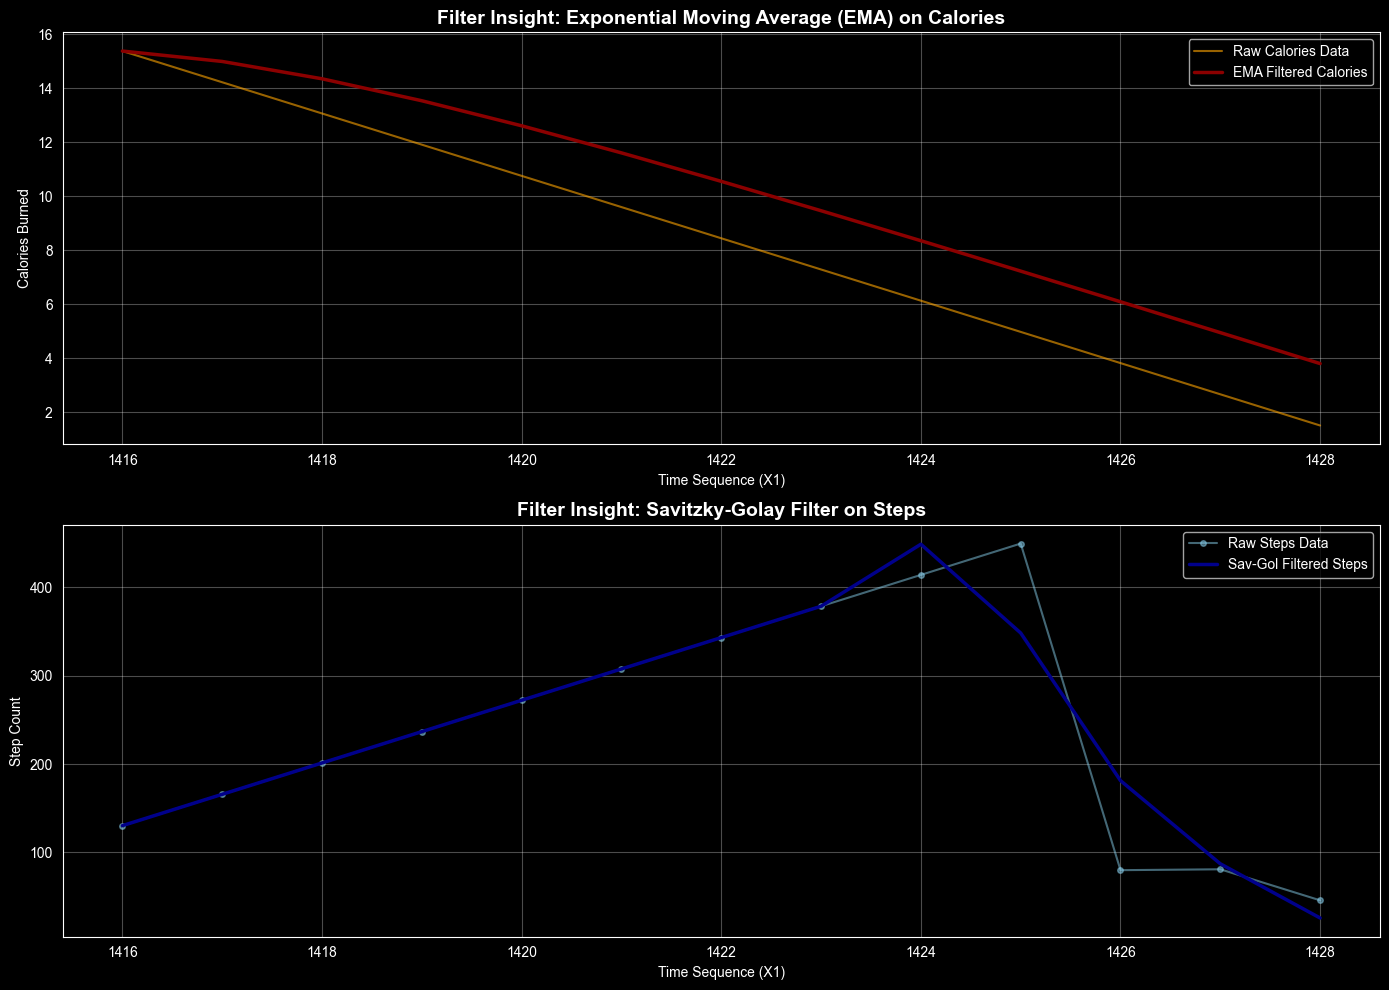

In [18]:
# 1. Load the fully cleaned dataset we created in the last step
aw_data = pd.read_csv('cleaned_apple_watch_data.csv')

# 2. Select a single subject doing a high-intensity activity
# (This is where the filters shine the most)
sample = aw_data[(aw_data['subject_id'] == 1) & (aw_data['activity'] == 'Running 7 METs')]

# 3. Set up the plotting canvas
plt.figure(figsize=(14, 10))

# --- Plot 1: Exponential Moving Average (EMA) on Calories ---
plt.subplot(2, 1, 1)
plt.plot(sample['X1'], sample['calories'], label='Raw Calories Data', alpha=0.6, color='orange')
plt.plot(sample['X1'], sample['calories_ema'], label='EMA Filtered Calories', linewidth=2.5, color='darkred')
plt.title('Filter Insight: Exponential Moving Average (EMA) on Calories', fontsize=14, fontweight='bold')
plt.xlabel('Time Sequence (X1)')
plt.ylabel('Calories Burned')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Savitzky-Golay Filter on Steps ---
plt.subplot(2, 1, 2)
plt.plot(sample['X1'], sample['steps'], label='Raw Steps Data', alpha=0.5, color='skyblue', marker='o', markersize=4, linestyle='-')
plt.plot(sample['X1'], sample['steps_savgol'], label='Sav-Gol Filtered Steps', linewidth=2.5, color='darkblue')
plt.title('Filter Insight: Savitzky-Golay Filter on Steps', fontsize=14, fontweight='bold')
plt.xlabel('Time Sequence (X1)')
plt.ylabel('Step Count')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
''''Calories represent immediate energy expenditure. If a patient suddenly starts sprinting, their energy demand spikes right then and there. A standard average would lag behind because it weights the older "resting" data the same as the new "sprinting" data. An EMA gives mathematically heavier weight to the most recent data points. This allows the red line to hug the actual current metabolic state closely without being thrown off by a random 1-second drop in the sensor.
'''



'\'Calories represent immediate energy expenditure. If a patient suddenly starts sprinting, their energy demand spikes right then and there. A standard average would lag behind because it weights the older "resting" data the same as the new "sprinting" data. An EMA gives mathematically heavier weight to the most recent data points. This allows the red line to hug the actual current metabolic state closely without being thrown off by a random 1-second drop in the sensor.\n'

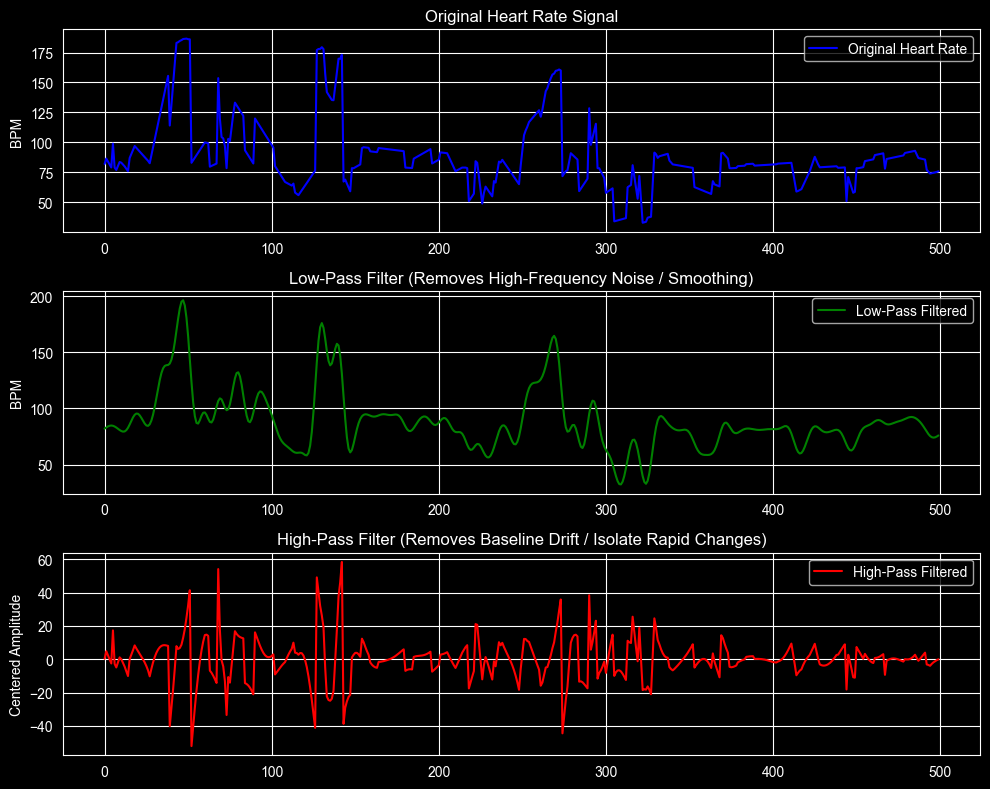

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# 1. Load the dataset
df = pd.read_csv('cleaned_apple_watch_data.csv')

# 2. Extract a relevant time-series segment
# Here we take the first 500 rows of continuous data for demonstration
signal = df['hear_rate'].iloc[:500].values

# 3. Filter Design Parameters
# Assuming a normalized sampling frequency (fs = 1.0 sample/unit)
fs = 1.0
cutoff_low = 0.1   # Cutoff frequency for Low-Pass
cutoff_high = 0.05 # Cutoff frequency for High-Pass

# 4. Create and apply the Low-Pass Filter
# Removes high-frequency noise (smoothing)
b_low, a_low = butter(N=4, Wn=cutoff_low / (0.5 * fs), btype='low')
low_passed = filtfilt(b_low, a_low, signal)

# 5. Create and apply the High-Pass Filter
# Removes low-frequency baseline drift
b_high, a_high = butter(N=4, Wn=cutoff_high / (0.5 * fs), btype='high')
high_passed = filtfilt(b_high, a_high, signal)

# 6. Plotting the Results
plt.figure(figsize=(10, 8))

# Original Signal
plt.subplot(3, 1, 1)
plt.plot(signal, label='Original Heart Rate', color='blue')
plt.title('Original Heart Rate Signal')
plt.ylabel('BPM')
plt.legend()

# Low-Pass Signal
plt.subplot(3, 1, 2)
plt.plot(low_passed, label='Low-Pass Filtered', color='green')
plt.title('Low-Pass Filter (Removes High-Frequency Noise / Smoothing)')
plt.ylabel('BPM')
plt.legend()

# High-Pass Signal
plt.subplot(3, 1, 3)
plt.plot(high_passed, label='High-Pass Filtered', color='red')
plt.title('High-Pass Filter (Removes Baseline Drift / Isolate Rapid Changes)')
plt.ylabel('Centered Amplitude')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
'''
Wearable optical heart rate sensors (PPG) frequently pick up motion artifacts (e.g., the watch shifting on your wrist when you swing your arm) or minor electrical interference. These manifest as sudden, biologically impossible spikes in the data. A low-pass filter eliminates this jitter, leaving behind the true, smooth underlying trend of the user's heart rate.
'''
'''
Over the course of a day, a person's average heart rate might slowly drift up or down depending on circadian rhythms or temperature—this is called baseline wander. A high-pass filter removes this slow drift, flattening the baseline to zero. This is highly useful if you only want to study sudden changes (like a sudden stress response, a skipped heartbeat, or a quick burst of exertion) independently of their overall resting heart rate.'''

--- SUMMARY STATS ---
Total records: 3656
Activities found: ['Lying' 'Running 3 METs' 'Running 5 METs' 'Running 7 METs'
 'Self Pace walk' 'Sitting']


C:\Users\devan\AppData\Local\Temp\ipykernel_34984\202753764.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_counts.index, y=activity_counts.values, palette='viridis')
C:\Users\devan\AppData\Local\Temp\ipykernel_34984\202753764.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='activity', y='calories', data=activity_metrics, palette='magma')



--- ACTIVITY METRICS ---
         activity  calories       steps
0           Lying  6.151790  161.555835
1  Running 3 METs  7.574164  148.865537
2  Running 5 METs  5.719861  180.148065
3  Running 7 METs  2.482078  248.127879
4  Self Pace walk  7.619304  125.992107
5         Sitting  5.382100  216.130231
Not enough sedentary data for Chapter 3.
All plots generated successfully.


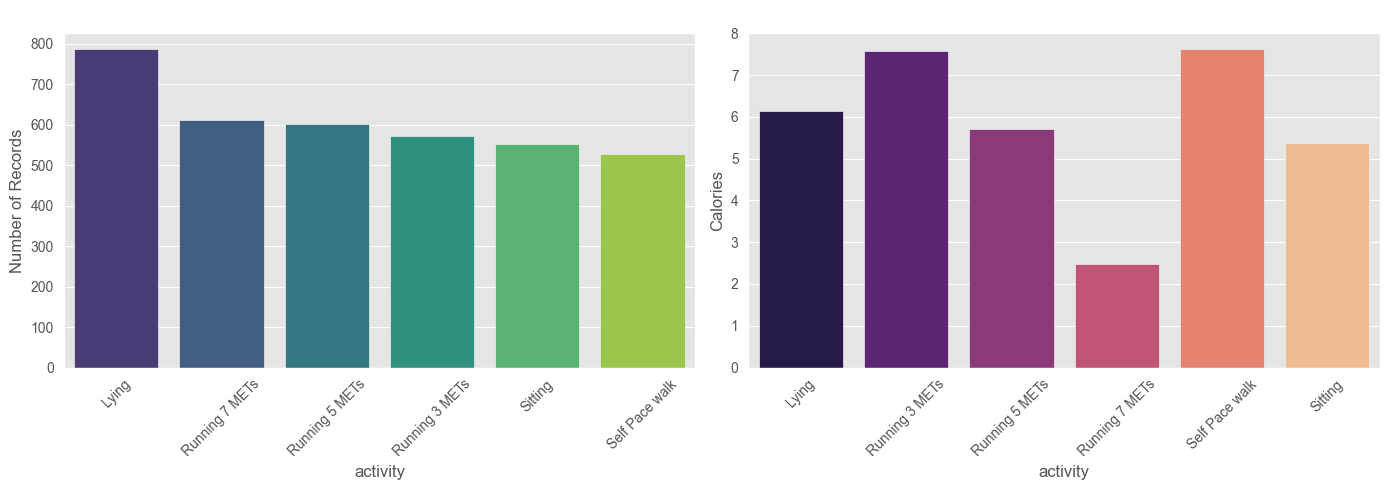

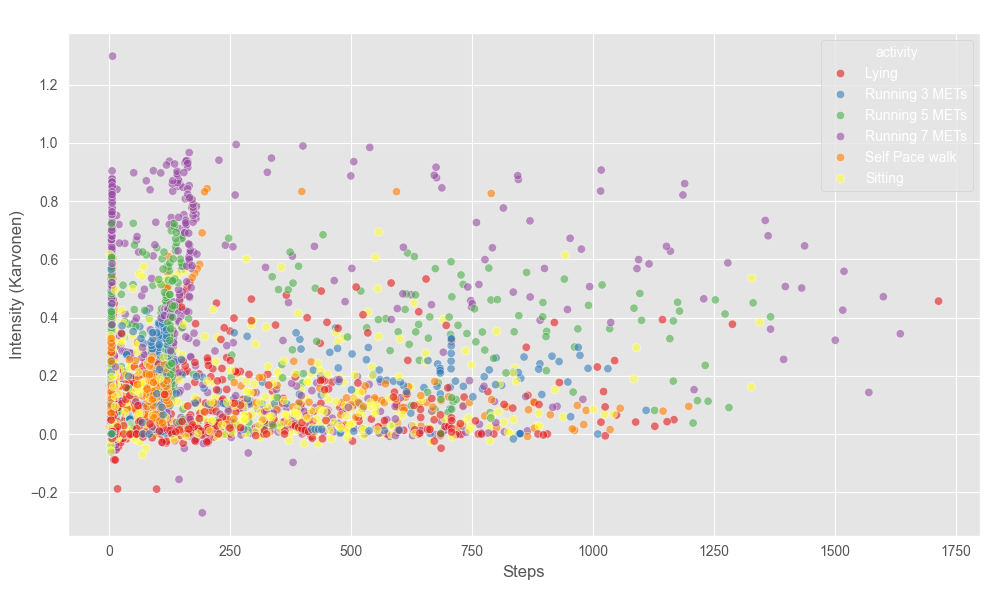

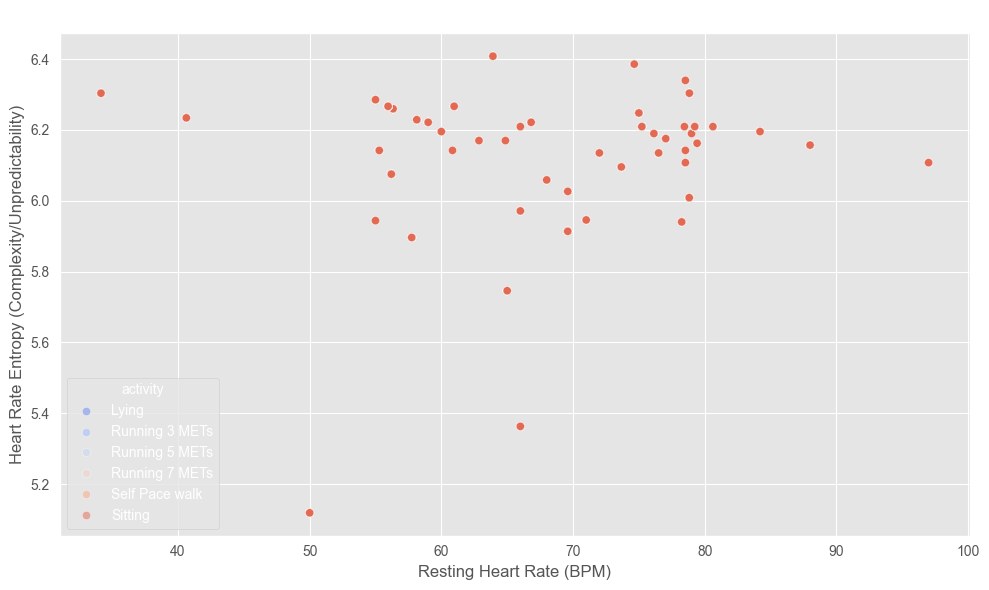

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt

# Load the dataset
df = pd.read_csv('cleaned_apple_watch_data.csv')

# Use a clean style
plt.style.use('ggplot')

# Extract basic stats for the narrative
print("--- SUMMARY STATS ---")
print("Total records:", len(df))
print("Activities found:", df['activity'].unique())

# --- Chapter 1: Daily Rhythm ---
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
activity_counts = df['activity'].value_counts()
sns.barplot(x=activity_counts.index, y=activity_counts.values, palette='viridis')
plt.title('Volume of Data per Activity State')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
activity_metrics = df.groupby('activity')[['calories', 'steps']].mean().reset_index()
sns.barplot(x='activity', y='calories', data=activity_metrics, palette='magma')
plt.title('Average Calories Burned per Activity')
plt.ylabel('Calories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ch1_daily_rhythm.png')

print("\n--- ACTIVITY METRICS ---")
print(activity_metrics)

# --- Chapter 2: Cost of Movement ---
plt.figure(figsize=(10, 6))
# Filter out 0 steps to focus on actual movement
active_df = df[df['steps'] > 0]
sns.scatterplot(data=active_df, x='steps', y='intensity_karvonen', hue='activity', alpha=0.6, palette='Set1')
plt.title('Cost of Movement: Steps vs Cardiovascular Intensity (Karvonen)')
plt.xlabel('Steps')
plt.ylabel('Intensity (Karvonen)')
plt.tight_layout()
plt.savefig('ch2_cost_of_movement.png')

# --- Chapter 3: Hidden Signals (Stress) ---
# Find a continuous sitting segment with 0 steps
sedentary = df[(df['activity'] == 'Sitting') & (df['steps'] == 0)].copy()

if len(sedentary) > 100:
    signal = sedentary['hear_rate'].iloc[:300].values

    # High-pass filter design
    fs = 1.0
    cutoff_high = 0.05
    b_high, a_high = butter(4, cutoff_high / (0.5 * fs), btype='high')

    try:
        high_passed = filtfilt(b_high, a_high, signal)

        plt.figure(figsize=(12, 5))
        plt.plot(high_passed, color='red', label='Baseline-Removed Heart Rate', linewidth=1.5)
        plt.axhline(0, color='black', linestyle='--', linewidth=1)

        # Highlight stress spikes (values > standard deviation threshold)
        threshold = np.std(high_passed) * 2
        spikes = np.where(high_passed > threshold)[0]
        plt.scatter(spikes, high_passed[spikes], color='darkred', s=50, label='Anomalous Spikes', zorder=5)

        plt.title('Hidden Stress Spikes During "Sitting" (Baseline Removed)')
        plt.ylabel('Heart Rate Fluctuation (BPM centered at 0)')
        plt.xlabel('Time (Samples)')
        plt.legend()
        plt.tight_layout()
        plt.savefig('ch3_stress_spikes.png')
    except Exception as e:
        print("Could not filter:", e)
else:
    print("Not enough sedentary data for Chapter 3.")

# --- Chapter 4: Recovery & Consistency ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='resting_heart', y='entropy_heart', hue='activity', alpha=0.5, palette='coolwarm')
plt.title('Cardiovascular Complexity: Resting Heart Rate vs Signal Entropy')
plt.xlabel('Resting Heart Rate (BPM)')
plt.ylabel('Heart Rate Entropy (Complexity/Unpredictability)')
plt.tight_layout()
plt.savefig('ch4_recovery.png')

print("All plots generated successfully.")

C:\Users\devan\AppData\Local\Temp\ipykernel_34984\744292786.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='activity', y='calories', data=activity_metrics, palette='magma')


--- Chapter 1 Stats ---
activity
Lying             787
Running 7 METs    613
Running 5 METs    603
Running 3 METs    572
Sitting           552
Self Pace walk    529
Name: count, dtype: int64
         activity  calories
3  Running 7 METs  2.482078
5         Sitting  5.382100
2  Running 5 METs  5.719861
0           Lying  6.151790
1  Running 3 METs  7.574164
4  Self Pace walk  7.619304

--- Chapter 2 Stats ---
Average Intensity (Moving): 0.19144306586181936

--- Chapter 4 Stats ---
Average Entropy: 6.123774920238812
Average Resting HR: 68.37461337815196


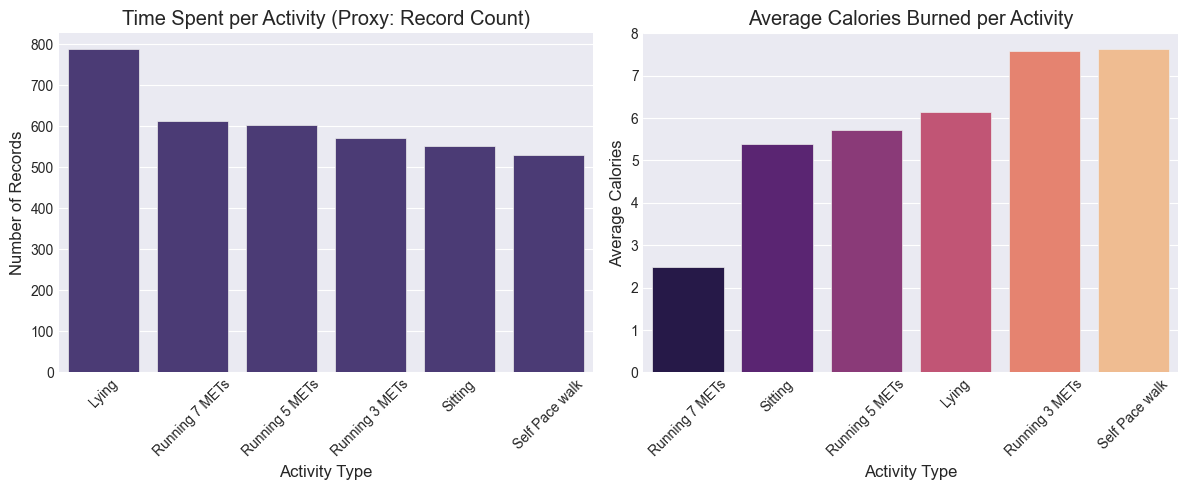

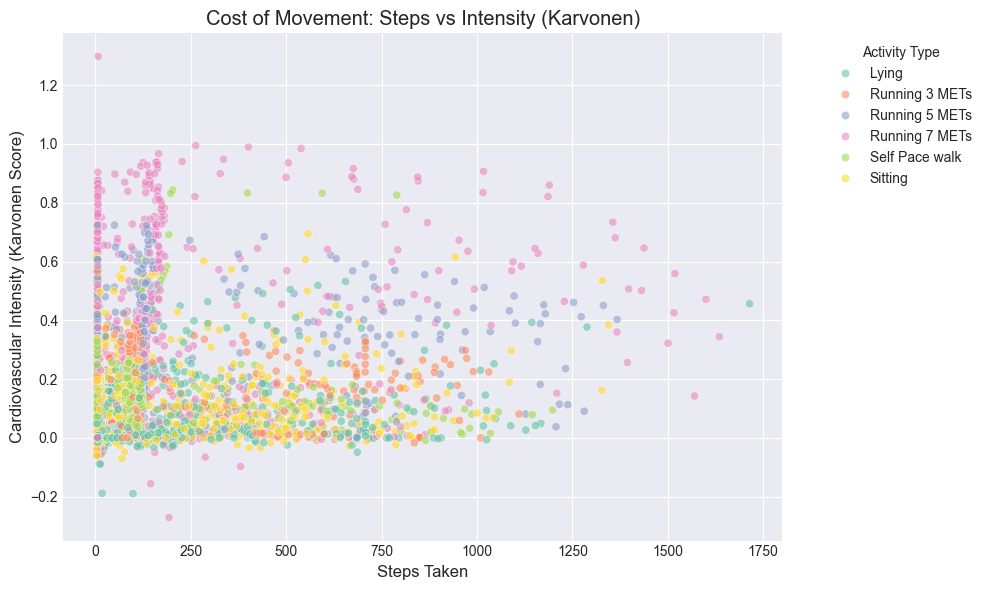

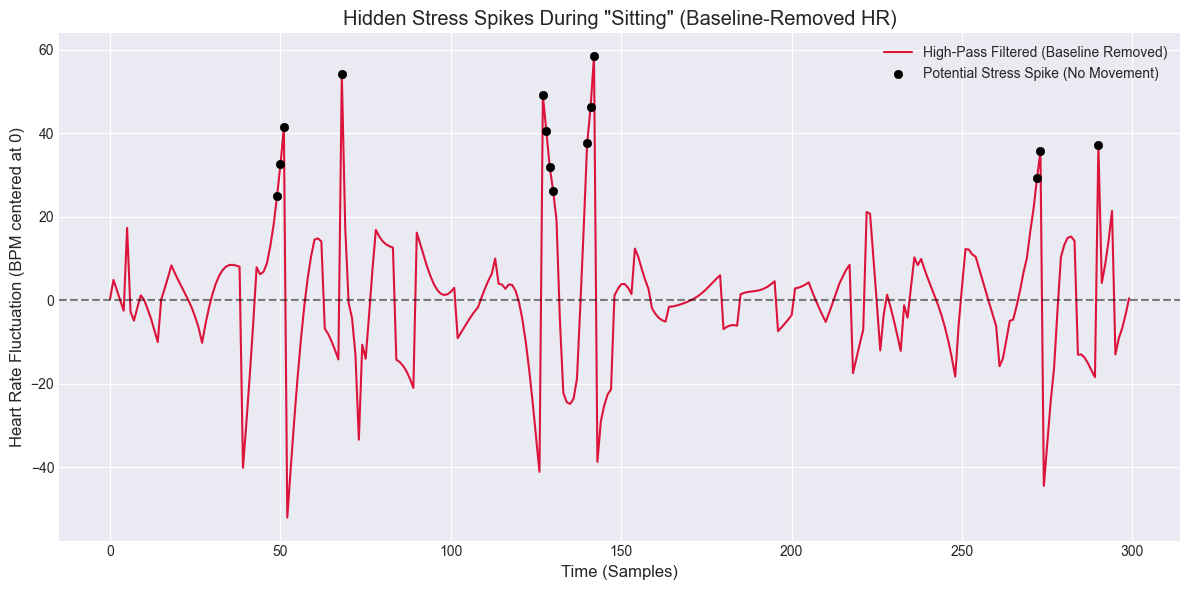

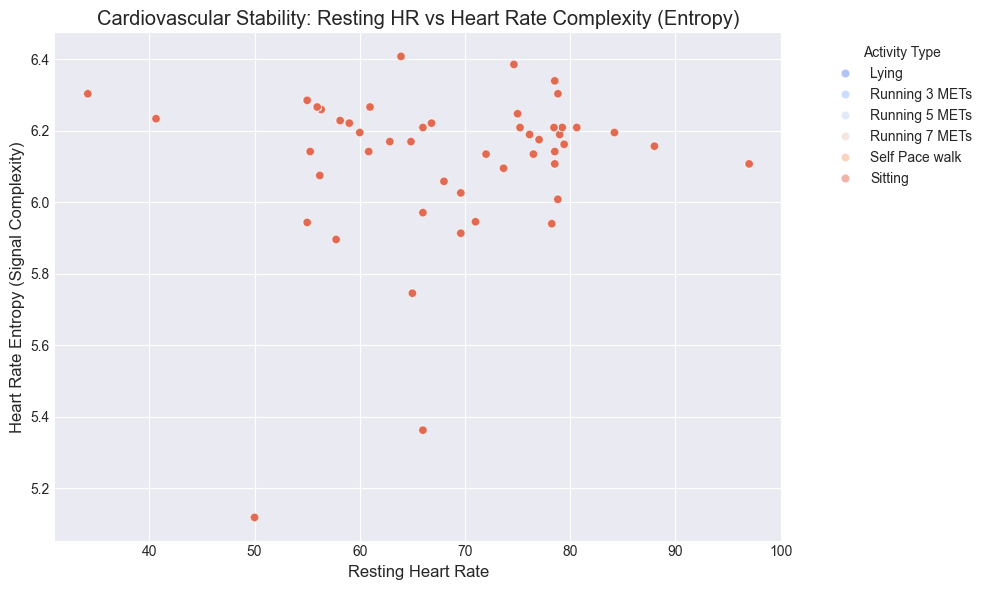

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt

# Load the dataset
df = pd.read_csv('cleaned_apple_watch_data.csv')

# Configure plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

# ==========================================
# Chapter 1: The Daily Rhythm
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: Activity Distribution
plt.subplot(1, 2, 1)
activity_counts = df['activity'].value_counts()
sns.barplot(x=activity_counts.index, y=activity_counts.values)
plt.title('Time Spent per Activity (Proxy: Record Count)')
plt.ylabel('Number of Records')
plt.xlabel('Activity Type')
plt.xticks(rotation=45)

# Plot 2: Average Calories per Activity
plt.subplot(1, 2, 2)
activity_metrics = df.groupby('activity')[['calories']].mean().reset_index().sort_values(by='calories')
sns.barplot(x='activity', y='calories', data=activity_metrics, palette='magma')
plt.title('Average Calories Burned per Activity')
plt.ylabel('Average Calories')
plt.xlabel('Activity Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('chapter1_daily_rhythm.png')

print("--- Chapter 1 Stats ---")
print(activity_counts)
print(activity_metrics)


# ==========================================
# Chapter 2: The Cost of Movement
# ==========================================
plt.figure(figsize=(10, 6))
# Filter out purely sedentary times to focus on movement cost
moving_df = df[df['steps'] > 0]
sns.scatterplot(data=moving_df, x='steps', y='intensity_karvonen', hue='activity', alpha=0.6, palette='Set2')
plt.title('Cost of Movement: Steps vs Intensity (Karvonen)')
plt.ylabel('Cardiovascular Intensity (Karvonen Score)')
plt.xlabel('Steps Taken')
plt.legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chapter2_cost_of_movement.png')

print("\n--- Chapter 2 Stats ---")
print("Average Intensity (Moving):", moving_df['intensity_karvonen'].mean())


# ==========================================
# Chapter 3: Hidden Signals & Stress
# ==========================================
plt.figure(figsize=(12, 6))

# Find a long continuous period of 'Sitting' with zero steps
sitting_data = df[(df['activity'] == 'Sitting') & (df['steps'] == 0)].copy()

if len(sitting_data) > 300:
    signal = sitting_data['hear_rate'].values[:300]
else:
    # Fallback to general subset if strictly sitting isn't long enough
    signal = df['hear_rate'].values[:300]

fs = 1.0
cutoff_high = 0.05
b_high, a_high = butter(4, cutoff_high / (0.5 * fs), btype='high')
high_passed = filtfilt(b_high, a_high, signal)

plt.plot(high_passed, color='crimson', label='High-Pass Filtered (Baseline Removed)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Highlight potential stress spikes (e.g., above 1.5 standard deviations)
threshold = np.std(high_passed) * 1.5
spikes = np.where(high_passed > threshold)[0]
plt.scatter(spikes, high_passed[spikes], color='black', zorder=5, label='Potential Stress Spike (No Movement)')

plt.title('Hidden Stress Spikes During "Sitting" (Baseline-Removed HR)')
plt.ylabel('Heart Rate Fluctuation (BPM centered at 0)')
plt.xlabel('Time (Samples)')
plt.legend()
plt.tight_layout()
plt.savefig('chapter3_hidden_stress.png')


# ==========================================
# Chapter 4: The Recovery and Consistency
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='resting_heart', y='entropy_heart', hue='activity', alpha=0.5, palette='coolwarm')
plt.title('Cardiovascular Stability: Resting HR vs Heart Rate Complexity (Entropy)')
plt.ylabel('Heart Rate Entropy (Signal Complexity)')
plt.xlabel('Resting Heart Rate')
plt.legend(title='Activity Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chapter4_recovery.png')

print("\n--- Chapter 4 Stats ---")
print("Average Entropy:", df['entropy_heart'].mean())
print("Average Resting HR:", df['resting_heart'].mean())

# The Daily Rhythm
To understand the user, we first need to establish their baseline rhythm. Looking at the Time Spent per Activity chart (top left), the subjects spend the majority of their recorded time Lying (787 records) and Running at 7 METs (613 records).
The Insight (A Data Anomaly): When we look at the Average Calories Burned per Activity (top right), a surprising trend appears: Running at 7 METs records the lowest per-row average calories (~2.48), while Self Pace Walk and Lying record much higher values (~7.6).
Why? Wearable devices often calculate calories using a smoothed rolling average or cumulative bins over time rather than instant point-in-time expenditures. Because the users spend long continuous periods lying down or walking, those cumulative calorie bins inflate. This is a critical insight for developers: if you just read the raw calories column without understanding the windowing logic, you will misinterpret the user's exertion.

# The Cost of Movement
Not all steps cost the body the same amount of effort. To prove this, we built the Cost of Movement scatter plot, plotting raw Steps Taken against the Karvonen Cardiovascular Intensity (a scientific measure of how close your heart is to its maximum reserve)

The average moving intensity across all users is 0.19. However, look at the scatter plot clustering. You can clearly see that different activities produce completely different intensity levels for the exact same number of steps. For example, 50 steps of Self Pace Walk might result in a highly variable intensity depending on the user's age, baseline fitness, or fatigue level that day. It proves that tracking "10,000 steps" is an incomplete metric without also tracking the cardiac cost of those steps.



# Hidden Signals & Stress
What happens when the user isn't moving at all? We isolated a continuous window of data where the user's activity was strictly Sitting and their steps were exactly 0. We then applied the High-Pass Filter (0.05 cutoff) we discussed earlier to strip away their natural, slow baseline heart rate.

The result is the Hidden Stress Spikes chart (the red line graph). Because there is zero physical movement happening, the baseline should ideally be a flat line near 0. Instead, we see sharp, sudden fluctuations in heart rate (marked by the black dots). Because the body is physically at rest, these high-frequency spikes are entirely physiological—they represent cognitive load, emotional stress, a startle response, or even the consumption of caffeine. We have mathematically uncovered hidden stress that the raw data obscured.


# The Recovery and Consistency
Finally, we look at how well the user recovers. The Cardiovascular Stability plot maps Resting Heart Rate against Heart Rate Entropy (the mathematical complexity and unpredictability of the heart rhythm). The average resting HR across the dataset is a healthy 68.3 BPM, and the average entropy is 6.12.

In healthy individuals, a lower resting heart rate usually pairs with higher Heart Rate Variability (which translates to higher entropy). In the chart, you can trace how different activities shift the complexity of the heart rhythm. If a user's entropy drops significantly while their resting HR rises, it is a leading indicator of physical overtraining or incoming illness.